In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import random
import os
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# ===============================
# 資料集與增強方法
# ===============================
class TimeSeriesDataset(Dataset):
    def __init__(self, data):
        # data shape: (N, channels, series_length)
        if isinstance(data, np.ndarray):
            self.data = torch.from_numpy(data)
        else:
            self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]

def generate_test_data(num_series=200, series_length=128, channels=1):
    test_data = []
    labels = []
    t = np.linspace(0, 2*np.pi, series_length)
    for i in range(num_series):
        series = np.sin(t) + np.random.normal(0, 0.1, series_length)
        label = 0
        if random.random() < 0.3:
            start = random.randint(0, series_length - 20)
            series[start:start+20] += np.random.normal(0, 1.0, 20)
            label = 1
        test_data.append(series.reshape(channels, series_length))
        labels.append(label)
    test_data = np.array(test_data, dtype=np.float32)
    return test_data, labels

def strong_augmentation(x, noise_std=0.05):
    """
    強增強：加入較大噪聲與隨機縮放
    """
    noise = torch.randn_like(x) * noise_std
    scale = torch.empty(x.size(0), 1, 1, device=x.device).uniform_(0.8, 1.2)
    return x * scale + noise

def weak_augmentation(x, noise_std=0.01):
    """
    弱增強：僅加入微小噪聲
    """
    noise = torch.randn_like(x) * noise_std
    return x + noise

# ===============================
# 對比損失函數
# ===============================
def nt_xent_loss(z1, z2, temperature=0.5):
    """
    z1, z2: shape [N, d]
    """
    N = z1.shape[0]
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    representations = torch.cat([z1, z2], dim=0)  # (2N, d)
    similarity_matrix = torch.matmul(representations, representations.T)
    mask = (~torch.eye(2 * N, 2 * N, dtype=bool, device=z1.device)).float()
    sim_exp = torch.exp(similarity_matrix / temperature)
    denom = torch.sum(sim_exp * mask, dim=1)
    pos_sim = torch.exp(torch.sum(z1 * z2, dim=1) / temperature)
    pos_sim = torch.cat([pos_sim, pos_sim], dim=0)
    loss = -torch.log(pos_sim / (denom + 1e-8) + 1e-8)
    return loss.mean()
    
def temporal_contrast_loss(local_strong, local_weak, temperature=0.5):
    # local_strong, local_weak: [batch, L, d]
    batch, L, d = local_strong.size()
    strong_flat = local_strong.reshape(batch * L, d)
    weak_flat = local_weak.reshape(batch * L, d)
    return nt_xent_loss(strong_flat, weak_flat, temperature)

def contextual_contrast_loss(global_strong, global_weak, temperature=0.5):
    # global_strong, global_weak: [batch, d]
    return nt_xent_loss(global_strong, global_weak, temperature)

def ts_tcc_loss(local_strong, global_strong, local_weak, global_weak, temperature=0.5, lambda_t=0.5):
    """
    TS-TCC Loss：L = lambda_t * L_temporal + (1 - lambda_t) * L_contextual
    strong view 用於局部（temporal）對比，weak view 用於全局（contextual）對比
    """
    loss_temp = temporal_contrast_loss(local_strong, local_weak, temperature)
    loss_context = contextual_contrast_loss(global_strong, global_weak, temperature)
    return lambda_t * loss_temp + (1 - lambda_t) * loss_context

# ===============================
# 模型架構：Decoder、Critic、Encoder
# ===============================
class TimeSeriesDecoder(nn.Module):
    def __init__(self, latent_dim=100, series_length=128, channels=1):
        super(TimeSeriesDecoder, self).__init__()
        self.latent_dim = latent_dim
        self.series_length = series_length
        self.channels = channels
        self.hidden_dim = 128
        self.fc = nn.Linear(latent_dim, self.hidden_dim * (series_length // 4))
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(self.hidden_dim, self.hidden_dim // 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(self.hidden_dim // 2),
            nn.ReLU(True),
            nn.ConvTranspose1d(self.hidden_dim // 2, channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # 輸出範圍 [-1, 1]
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.hidden_dim, self.series_length // 4)
        x = self.deconv(x)
        return x

class TimeSeriesCritic(nn.Module):
    def __init__(self, series_length=128, channels=1):
        super(TimeSeriesCritic, self).__init__()
        self.series_length = series_length
        self.channels = channels
        self.hidden_dim = 128
        self.conv = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(64, self.hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.fc = nn.Linear(self.hidden_dim * (series_length // 4), 1)
    
    def forward(self, x):
        features = self.conv(x)
        features = features.view(features.size(0), -1)
        out = self.fc(features)
        return out

class TS_TCC_Encoder(nn.Module):
    def __init__(self, channels=1, latent_dim=100):
        super(TS_TCC_Encoder, self).__init__()
        self.hidden_dim = 128
        self.conv = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, self.hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
        # 全局表徵：使用 AdaptiveAvgPool1d 池化後全連接映射
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(self.hidden_dim, latent_dim)
    
    def forward(self, x):
        # x: [batch, channels, length]
        features = self.conv(x)                   # [batch, hidden_dim, L]
        local_features = features.permute(0, 2, 1)  # [batch, L, hidden_dim]
        global_feat = self.pool(features).squeeze(2)  # [batch, hidden_dim]
        global_rep = self.fc(global_feat)            # [batch, latent_dim]
        return local_features, global_rep

# ===============================
# TS-TCC_WGAN 主架構：包含 TS-TCC Encoder、Decoder 與 Critic
# ===============================
class TS_TCC_WGAN:
    def __init__(self, dataset, latent_dim=100, series_length=128, channels=1, batch_size=64, lr=1e-4,
                 weight_clip=0.01, critic_iter=5, device=None, rec_loss_weight=10.0, lambda_t=0.5):
        """
        rec_loss_weight: 重構損失權重
        lambda_t: temporal loss 的權重（其餘作 contextual）
        """
        self.device = device if device is not None else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.latent_dim = latent_dim
        self.series_length = series_length
        self.channels = channels
        self.batch_size = batch_size
        self.lr = lr
        self.weight_clip = weight_clip
        self.critic_iter = critic_iter
        self.rec_loss_weight = rec_loss_weight
        self.lambda_t = lambda_t
        
        self.encoder = TS_TCC_Encoder(channels, latent_dim).to(self.device)
        self.decoder = TimeSeriesDecoder(latent_dim, series_length, channels).to(self.device)
        self.critic = TimeSeriesCritic(series_length, channels).to(self.device)
        
        self.dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
        
        # Optimizer for critic（WGAN 判別器）
        self.optim_C = optim.RMSprop(self.critic.parameters(), lr=lr)
        # Optimizer專門用於 TS-TCC contrastive loss 更新 encoder
        self.optim_E = optim.Adam(self.encoder.parameters(), lr=lr)
        # Optimizer 用於生成器更新（encoder 與 decoder 同時更新：重構+對抗損失）
        self.optim_G = optim.RMSprop(list(self.encoder.parameters()) + list(self.decoder.parameters()), lr=lr)
    
    def train(self, num_epochs=100):
        print(f"訓練開始，使用設備：{self.device}")
        for epoch in range(num_epochs):
            for i, real_data in enumerate(self.dataloader):
                real_data = real_data.to(self.device)
                batch_size = real_data.size(0)
                
                # ===== TS-TCC 對比學習 =====
                # 使用強增強與弱增強產生不同 view
                strong_view = strong_augmentation(real_data)
                weak_view = weak_augmentation(real_data)
                local_strong, global_strong = self.encoder(strong_view)
                local_weak, global_weak = self.encoder(weak_view)
                loss_contrast = ts_tcc_loss(local_strong, global_strong, local_weak, global_weak,
                                            temperature=0.5, lambda_t=self.lambda_t)
                
                self.optim_E.zero_grad()
                loss_contrast.backward(retain_graph=True)
                self.optim_E.step()
                
                # ===== 重構與 WGAN 對抗學習 =====
                # 使用原始資料經 encoder 得到 latent 表徵 (此處不 detach 使得 adversarial loss 也能反向更新 encoder)
                _, z = self.encoder(real_data)
                recon = self.decoder(z)
                rec_loss = F.l1_loss(recon, real_data)
                
                # ---- Critic 更新（WGAN）----
                for _ in range(self.critic_iter):
                    # critic 更新時，fake 使用 detach()，不更新生成器部分
                    fake = self.decoder(z.detach())
                    critic_real = self.critic(real_data)
                    critic_fake = self.critic(fake)
                    loss_C = -torch.mean(critic_real) + torch.mean(critic_fake)
                    
                    self.optim_C.zero_grad()
                    loss_C.backward()
                    self.optim_C.step()
                    
                    # 權重剪裁
                    for p in self.critic.parameters():
                        p.data.clamp_(-self.weight_clip, self.weight_clip)
                
                # ---- 生成器（Encoder + Decoder）更新 ----
                fake = self.decoder(z)  # 此處不 detach，允許 encoder 也參與更新
                loss_G_adv = -torch.mean(self.critic(fake))
                loss_G = self.rec_loss_weight * rec_loss + loss_G_adv
                
                self.optim_G.zero_grad()
                loss_G.backward()
                self.optim_G.step()
                
                total_loss = loss_contrast.item() + self.rec_loss_weight * rec_loss.item() + loss_G_adv.item()
                if i % 50 == 0:
                    print(f"[Epoch {epoch+1}/{num_epochs}] [批次 {i}/{len(self.dataloader)}] "
                          f"[TS-TCC Loss: {loss_contrast.item():.4f}] [Rec Loss: {rec_loss.item():.4f}] "
                          f"[WGAN G Loss: {loss_G_adv.item():.4f}] [Critic Loss: {loss_C.item():.4f}]")
        print("訓練完成。")
    
    def reconstruct(self, x):
        self.encoder.eval()
        self.decoder.eval()
        with torch.no_grad():
            _, z = self.encoder(x.to(self.device))
            recon = self.decoder(z)
        self.encoder.train()
        self.decoder.train()
        return z.cpu(), recon.cpu()
    
    def get_latent(self, x):
        self.encoder.eval()
        with torch.no_grad():
            _, z = self.encoder(x.to(self.device))
        self.encoder.train()
        return z.cpu()
    
    def get_model(self):
        return {"encoder": self.encoder, "decoder": self.decoder, "critic": self.critic}

# ===============================
# RLHF 部分
# ===============================
def ranking_loss(critic, preferred, non_preferred):
    score_pref = critic(preferred)
    score_nonpref = critic(non_preferred)
    loss = -torch.log(torch.sigmoid(score_pref - score_nonpref) + 1e-8)
    return loss.mean()

def rlhf_finetune(model, human_feedback, num_epochs=5, lambda_factor=0.5):
    device = model.device
    # 為 RLHF 微調使用 Adam optimizer，更新 encoder, decoder 與 critic（注意：此處 RLHF 與原有兩分支更新是獨立的）
    optimizer = optim.Adam(list(model.encoder.parameters()) + 
                           list(model.decoder.parameters()) + 
                           list(model.critic.parameters()), lr=model.lr)
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        for fb in human_feedback:
            sample1 = fb["sample1"].detach().clone().to(device).unsqueeze(0)
            sample2 = fb["sample2"].detach().clone().to(device).unsqueeze(0)
            if fb["preferred"] == 1:
                pos_sample = sample1
                neg_sample = sample2
            elif fb["preferred"] == 2:
                pos_sample = sample2
                neg_sample = sample1
            else:
                raise ValueError("preferred 欄位必須為 1 或 2")
            
            pos_aug = strong_augmentation(pos_sample)  # 使用強增強
            local_pos, global_pos = model.encoder(pos_sample)
            local_pos_aug, global_pos_aug = model.encoder(pos_aug)
            contrast_loss = ts_tcc_loss(local_pos, global_pos, local_pos_aug, global_pos_aug,
                                        temperature=0.5, lambda_t=0.5)
            
            r_loss = ranking_loss(model.critic, pos_sample, neg_sample)
            total_batch_loss = lambda_factor * r_loss + (1 - lambda_factor) * contrast_loss
            
            optimizer.zero_grad()
            total_batch_loss.backward()
            optimizer.step()
            
            total_loss += total_batch_loss.item()
        avg_loss = total_loss / len(human_feedback)
        print(f"[RLHF Epoch {epoch+1}/{num_epochs}] 平均損失: {avg_loss:.4f}")
    print("RLHF 微調完成。")

# ===============================
# 輔助函數：建模、CSV 資料生成與載入、TSNE 視覺化
# ===============================
def build_ts_tcc_wgan_model(dataset, latent_dim=100, series_length=128, channels=1, batch_size=64, lr=1e-4,
                            weight_clip=0.01, critic_iter=5, device=None, rec_loss_weight=10.0, lambda_t=0.5):
    model = TS_TCC_WGAN(dataset, latent_dim=latent_dim, series_length=series_length, channels=channels,
                          batch_size=batch_size, lr=lr, weight_clip=weight_clip, critic_iter=critic_iter,
                          device=device, rec_loss_weight=rec_loss_weight, lambda_t=lambda_t)
    return model

def generate_pair_data_csv(model, num_pairs=20, csv_path='pair_data.csv'):
    device = model.device
    latent_dim = model.latent_dim
    pair_list = []
    for i in range(num_pairs):
        z1 = torch.randn(1, latent_dim, device=device)
        z2 = torch.randn(1, latent_dim, device=device)
        sample1 = model.decoder(z1)
        sample2 = model.decoder(z2)
        sample1_mean = sample1.abs().mean().item()
        sample2_mean = sample2.abs().mean().item()
        preferred = 1 if sample1_mean > sample2_mean else 2
        pair_list.append({
            'pair_id': i,
            'sample1_mean': sample1_mean,
            'sample2_mean': sample2_mean,
            'preferred': preferred
        })
    df = pd.DataFrame(pair_list)
    df.to_csv(csv_path, index=False)
    print(f"Pair data 已儲存至 {csv_path}")
    return df

def load_human_feedback_from_csv(csv_path='pair_data.csv', model=None):
    df = pd.read_csv(csv_path)
    human_feedback = []
    latent_dim = model.latent_dim
    device = model.device
    for idx, row in df.iterrows():
        z1 = torch.randn(1, latent_dim, device=device)
        z2 = torch.randn(1, latent_dim, device=device)
        sample1 = model.decoder(z1).squeeze(0).cpu()
        sample2 = model.decoder(z2).squeeze(0).cpu()
        feedback = {"sample1": sample1, "sample2": sample2, "preferred": int(row['preferred'])}
        human_feedback.append(feedback)
    return human_feedback

def tsne_visualize(model, test_data, labels, window_size=32, stride=8):
    model.encoder.eval()
    all_latents = []
    all_colors = []
    expected_length = model.series_length  # e.g. 128
    for i in range(test_data.shape[0]):
        ts = torch.from_numpy(test_data[i]).unsqueeze(0)  # [1, channels, series_length]
        for start in range(0, ts.shape[-1]-window_size+1, stride):
            window = ts[:, :, start:start+window_size].to(model.device)
            if window.shape[-1] != expected_length:
                window = torch.nn.functional.interpolate(window, size=expected_length, mode='linear', align_corners=False)
            _, z = model.encoder(window)
            all_latents.append(z.squeeze(0).detach().cpu().numpy())
            all_colors.append('red' if labels[i]==1 else 'blue')
    all_latents = np.array(all_latents)
    tsne = TSNE(n_components=2, random_state=42)
    latent_2d = tsne.fit_transform(all_latents)
    
    plt.figure(figsize=(8,6))
    plt.scatter(latent_2d[:,0], latent_2d[:,1], c=all_colors, alpha=0.6)
    plt.title("[TSNE Visualization] Blue:Normal; Red:Abnormal")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.show()
    model.encoder.train()

In [17]:
import numpy as np

def sliding_window(arr, window_size, stride=1):
    """
    使用滑動視窗技術對 1D 或 2D 陣列進行分割
    :param arr: 輸入的 numpy 陣列
    :param window_size: 滑動視窗的大小 (tuple) -> (window_height, window_width) for 2D
    :param stride: 滑動視窗的步長 (tuple) -> (stride_y, stride_x) for 2D
    :return: 切割後的視窗陣列
    """
    arr = np.array(arr)  # 確保輸入為 numpy 陣列

    if arr.ndim == 1:
        # 1D 時間序列滑動窗口
        shape = ((arr.shape[0] - window_size) // stride + 1, window_size)
        strides = (arr.strides[0] * stride, arr.strides[0])
        return np.lib.stride_tricks.as_strided(arr, shape=shape, strides=strides)

    elif arr.ndim == 2:
        # 2D 影像或矩陣滑動窗口
        h, w = arr.shape
        win_h, win_w = window_size
        stride_y, stride_x = stride

        shape = ((h - win_h) // stride_y + 1,
                 (w - win_w) // stride_x + 1,
                 win_h, win_w)
        strides = (arr.strides[0] * stride_y,
                   arr.strides[1] * stride_x,
                   arr.strides[0],
                   arr.strides[1])

        return np.lib.stride_tricks.as_strided(arr, shape=shape, strides=strides)

    else:
        raise ValueError("只支援 1D 或 2D 陣列")


先進行初步訓練 (正常資料)...
訓練開始，使用設備：cuda
[Epoch 1/50] [批次 0/154] [TS-TCC Loss: 6.1777] [Rec Loss: 0.9162] [WGAN G Loss: 0.0118] [Critic Loss: -0.0042]
[Epoch 1/50] [批次 50/154] [TS-TCC Loss: 5.8195] [Rec Loss: 0.3610] [WGAN G Loss: 0.3766] [Critic Loss: -0.6601]
[Epoch 1/50] [批次 100/154] [TS-TCC Loss: 5.6169] [Rec Loss: 0.3156] [WGAN G Loss: 0.3151] [Critic Loss: -0.6789]
[Epoch 1/50] [批次 150/154] [TS-TCC Loss: 5.5036] [Rec Loss: 0.2936] [WGAN G Loss: 0.2561] [Critic Loss: -0.6080]
[Epoch 2/50] [批次 0/154] [TS-TCC Loss: 5.4980] [Rec Loss: 0.2965] [WGAN G Loss: 0.2494] [Critic Loss: -0.6003]
[Epoch 2/50] [批次 50/154] [TS-TCC Loss: 5.4785] [Rec Loss: 0.2687] [WGAN G Loss: 0.2224] [Critic Loss: -0.5407]
[Epoch 2/50] [批次 100/154] [TS-TCC Loss: 5.4059] [Rec Loss: 0.2609] [WGAN G Loss: 0.1994] [Critic Loss: -0.5094]
[Epoch 2/50] [批次 150/154] [TS-TCC Loss: 5.3508] [Rec Loss: 0.2400] [WGAN G Loss: 0.1788] [Critic Loss: -0.4813]
[Epoch 3/50] [批次 0/154] [TS-TCC Loss: 5.3633] [Rec Loss: 0.2375] [WGAN G Loss

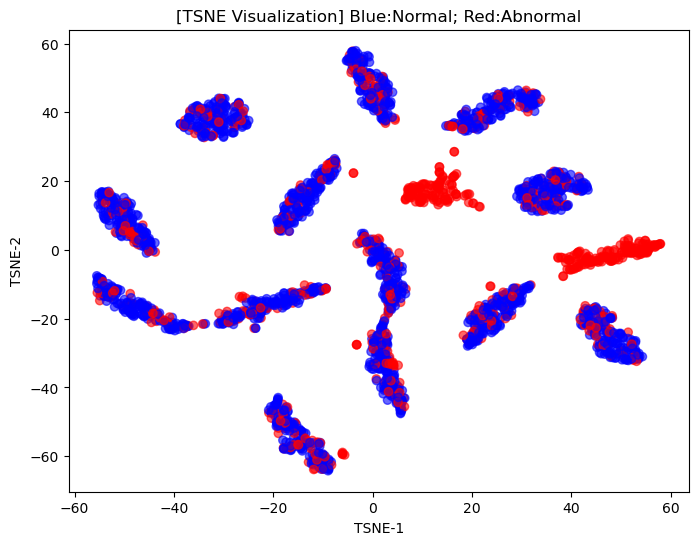

In [14]:
# ===============================
# 主程式入口
# ===============================
if __name__ == '__main__':
    # (1) 產生訓練資料：模擬正常時間序列
    num_train = 1000
    series_length = 128
    channels = 1
    train_data = sliding_window(np.sin(np.linspace(0, 10*np.pi, 10000)), series_length)
    train_data = train_data.reshape(-1, channels, series_length).astype(np.float32)
    train_dataset = TimeSeriesDataset(train_data)
    
    # (2) 建立模型並以正常資料訓練
    model = build_ts_tcc_wgan_model(train_dataset, latent_dim=100, series_length=series_length,
                                     channels=channels, batch_size=64, lr=1e-4)
    print("先進行初步訓練 (正常資料)...")
    model.train(num_epochs=50)
    
    # (3) 生成 pair 資料並存 CSV（供 human feedback 標記）
    csv_path = 'pair_data.csv'
    generate_pair_data_csv(model, num_pairs=20, csv_path=csv_path)
    
    # (4) 讀取 CSV 並進行 RLHF 微調
    human_feedback = load_human_feedback_from_csv(csv_path, model=model)
    print("開始 RLHF 微調...")
    rlhf_finetune(model, human_feedback, num_epochs=3, lambda_factor=0.5)
    
    # (5) 產生測試資料（正常與異常）
    test_data, test_labels = generate_test_data(num_series=200, series_length=series_length, channels=channels)
    
    # (6) 使用 TSNE 降維視覺化測試資料的 latent 分布
    tsne_visualize(model, test_data, test_labels, window_size=32, stride=8)


訓練資料數量: 153
訓練開始，使用設備：cuda
[Epoch 1/100] [批次 0/9] [TS-TCC Loss: 4.6255] [Rec Loss: 1.2228] [WGAN G Loss: -0.0011] [Center Loss: 0.0171] [Critic Loss: -0.0038]
[Epoch 2/100] [批次 0/9] [TS-TCC Loss: 4.4440] [Rec Loss: 0.9997] [WGAN G Loss: 0.0077] [Center Loss: 0.0177] [Critic Loss: -0.0214]
[Epoch 3/100] [批次 0/9] [TS-TCC Loss: 4.3642] [Rec Loss: 0.9277] [WGAN G Loss: 0.0144] [Center Loss: 0.0130] [Critic Loss: -0.0527]
[Epoch 4/100] [批次 0/9] [TS-TCC Loss: 4.2994] [Rec Loss: 0.9135] [WGAN G Loss: -0.0508] [Center Loss: 0.0120] [Critic Loss: -0.1013]
[Epoch 5/100] [批次 0/9] [TS-TCC Loss: 4.2346] [Rec Loss: 0.8580] [WGAN G Loss: -0.0859] [Center Loss: 0.0093] [Critic Loss: -0.1332]
[Epoch 6/100] [批次 0/9] [TS-TCC Loss: 4.1970] [Rec Loss: 0.8943] [WGAN G Loss: -0.2518] [Center Loss: 0.0110] [Critic Loss: -0.1607]
[Epoch 7/100] [批次 0/9] [TS-TCC Loss: 4.1767] [Rec Loss: 0.8818] [WGAN G Loss: -0.3110] [Center Loss: 0.0068] [Critic Loss: -0.2032]
[Epoch 8/100] [批次 0/9] [TS-TCC Loss: 4.1344] [Rec L

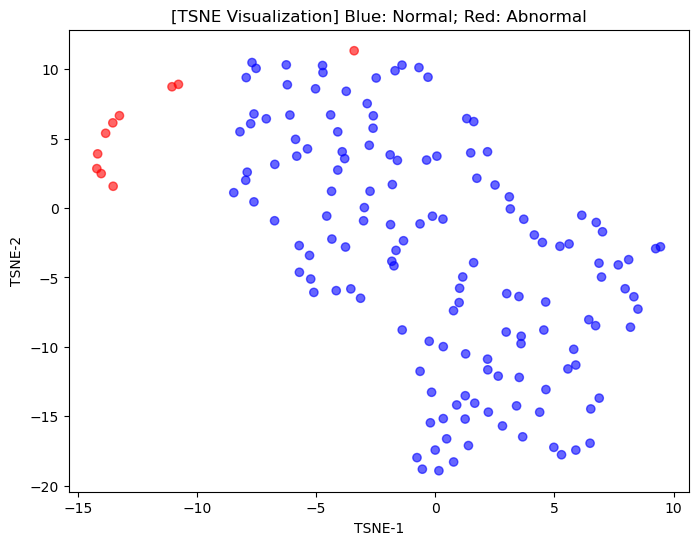

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import random
import os
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# ===============================
# 資料集與增強方法
# ===============================
class TimeSeriesDataset(Dataset):
    def __init__(self, data):
        # data shape: (N, channels, series_length)
        if isinstance(data, np.ndarray):
            self.data = torch.from_numpy(data)
        else:
            self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx]

def strong_augmentation(x, noise_std=0.05):
    """
    強增強：加入較大噪聲與隨機縮放
    """
    noise = torch.randn_like(x) * noise_std
    scale = torch.empty(x.size(0), 1, 1, device=x.device).uniform_(0.8, 1.2)
    return x * scale + noise

def weak_augmentation(x, noise_std=0.01):
    """
    弱增強：僅加入微小噪聲
    """
    noise = torch.randn_like(x) * noise_std
    return x + noise

# ===============================
# 對比損失函數
# ===============================
def nt_xent_loss(z1, z2, temperature=0.5):
    """
    z1, z2: shape [N, d]
    """
    N = z1.shape[0]
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    representations = torch.cat([z1, z2], dim=0)  # (2N, d)
    similarity_matrix = torch.matmul(representations, representations.T)
    mask = (~torch.eye(2 * N, 2 * N, dtype=bool, device=z1.device)).float()
    sim_exp = torch.exp(similarity_matrix / temperature)
    denom = torch.sum(sim_exp * mask, dim=1)
    pos_sim = torch.exp(torch.sum(z1 * z2, dim=1) / temperature)
    pos_sim = torch.cat([pos_sim, pos_sim], dim=0)
    loss = -torch.log(pos_sim / (denom + 1e-8) + 1e-8)
    return loss.mean()

def temporal_contrast_loss(local_strong, local_weak, temperature=0.5):
    # local_strong, local_weak: [batch, L, d]
    batch, L, d = local_strong.size()
    strong_flat = local_strong.reshape(batch * L, d)
    weak_flat = local_weak.reshape(batch * L, d)
    return nt_xent_loss(strong_flat, weak_flat, temperature)

def contextual_contrast_loss(global_strong, global_weak, temperature=0.5):
    # global_strong, global_weak: [batch, d]
    return nt_xent_loss(global_strong, global_weak, temperature)

def ts_tcc_loss(local_strong, global_strong, local_weak, global_weak, temperature=0.5, lambda_t=0.5):
    """
    TS-TCC Loss：L = lambda_t * L_temporal + (1 - lambda_t) * L_contextual
    strong view 用於局部（temporal）對比，weak view 用於全局（contextual）對比
    """
    loss_temp = temporal_contrast_loss(local_strong, local_weak, temperature)
    loss_context = contextual_contrast_loss(global_strong, global_weak, temperature)
    return lambda_t * loss_temp + (1 - lambda_t) * loss_context

# ===============================
# 模型架構：Decoder、Critic、Encoder
# ===============================
class TimeSeriesDecoder(nn.Module):
    def __init__(self, latent_dim=100, series_length=128, channels=1):
        super(TimeSeriesDecoder, self).__init__()
        self.latent_dim = latent_dim
        self.series_length = series_length
        self.channels = channels
        self.hidden_dim = 128
        self.fc = nn.Linear(latent_dim, self.hidden_dim * (series_length // 4))
        self.deconv = nn.Sequential(
            nn.ConvTranspose1d(self.hidden_dim, self.hidden_dim // 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(self.hidden_dim // 2),
            nn.ReLU(True),
            nn.ConvTranspose1d(self.hidden_dim // 2, channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # 輸出範圍 [-1, 1]
        )
    
    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.hidden_dim, self.series_length // 4)
        x = self.deconv(x)
        return x

class TimeSeriesCritic(nn.Module):
    def __init__(self, series_length=128, channels=1):
        super(TimeSeriesCritic, self).__init__()
        self.series_length = series_length
        self.channels = channels
        self.hidden_dim = 128
        self.conv = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(64, self.hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.fc = nn.Linear(self.hidden_dim * (series_length // 4), 1)
    
    def forward(self, x):
        features = self.conv(x)
        features = features.view(features.size(0), -1)
        out = self.fc(features)
        return out

class TS_TCC_Encoder(nn.Module):
    def __init__(self, channels=1, latent_dim=100):
        super(TS_TCC_Encoder, self).__init__()
        self.hidden_dim = 128
        self.conv = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv1d(64, self.hidden_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True)
        )
        # 全局表徵：使用 AdaptiveAvgPool1d 池化後全連接映射
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(self.hidden_dim, latent_dim)
    
    def forward(self, x):
        # x: [batch, channels, length]
        features = self.conv(x)                   # [batch, hidden_dim, L]
        local_features = features.permute(0, 2, 1)  # [batch, L, hidden_dim]
        global_feat = self.pool(features).squeeze(2)  # [batch, hidden_dim]
        global_rep = self.fc(global_feat)            # [batch, latent_dim]
        return local_features, global_rep

# ===============================
# TS-TCC_WGAN 主架構：包含 TS-TCC Encoder、Decoder 與 Critic
# ===============================
class TS_TCC_WGAN:
    def __init__(self, dataset, latent_dim=100, series_length=128, channels=1, batch_size=64, lr=1e-4,
                 weight_clip=0.01, critic_iter=5, device=None, rec_loss_weight=10.0, lambda_t=0.5,
                 center_loss_weight=0.1):
        """
        rec_loss_weight: 重構損失權重
        lambda_t: temporal loss 的權重（其餘作 contextual）
        center_loss_weight: 中心損失權重，用以使正常樣態的 latent 表徵收斂
        """
        self.device = device if device is not None else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.latent_dim = latent_dim
        self.series_length = series_length
        self.channels = channels
        self.batch_size = batch_size
        self.lr = lr
        self.weight_clip = weight_clip
        self.critic_iter = critic_iter
        self.rec_loss_weight = rec_loss_weight
        self.lambda_t = lambda_t
        self.center_loss_weight = center_loss_weight
        
        self.encoder = TS_TCC_Encoder(channels, latent_dim).to(self.device)
        self.decoder = TimeSeriesDecoder(latent_dim, series_length, channels).to(self.device)
        self.critic = TimeSeriesCritic(series_length, channels).to(self.device)
        
        self.dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
        
        # Optimizer for critic（WGAN 判別器）
        self.optim_C = optim.RMSprop(self.critic.parameters(), lr=lr)
        # Optimizer 專門用於 TS-TCC contrastive loss 更新 encoder
        self.optim_E = optim.Adam(self.encoder.parameters(), lr=lr)
        # Optimizer 用於生成器更新（encoder 與 decoder 同時更新：重構+對抗損失+中心損失）
        self.optim_G = optim.RMSprop(list(self.encoder.parameters()) + list(self.decoder.parameters()), lr=lr)
        
        # 設定正常樣態在 latent space 的中心（這裡預設為零向量）
        self.normal_center = torch.zeros(latent_dim, device=self.device)
    
    def train(self, num_epochs=100):
        print(f"訓練開始，使用設備：{self.device}")
        for epoch in range(num_epochs):
            for i, real_data in enumerate(self.dataloader):
                real_data = real_data.to(self.device)
                batch_size = real_data.size(0)
                
                # ===== TS-TCC 對比學習 =====
                strong_view = strong_augmentation(real_data)
                weak_view = weak_augmentation(real_data)
                local_strong, global_strong = self.encoder(strong_view)
                local_weak, global_weak = self.encoder(weak_view)
                loss_contrast = ts_tcc_loss(local_strong, global_strong, local_weak, global_weak,
                                            temperature=0.5, lambda_t=self.lambda_t)
                
                self.optim_E.zero_grad()
                loss_contrast.backward(retain_graph=True)
                self.optim_E.step()
                
                # ===== 重構與 WGAN 對抗學習 =====
                _, z = self.encoder(real_data)
                recon = self.decoder(z)
                rec_loss = F.l1_loss(recon, real_data)
                
                # ---- Critic 更新（WGAN）----
                for _ in range(self.critic_iter):
                    fake = self.decoder(z.detach())
                    critic_real = self.critic(real_data)
                    critic_fake = self.critic(fake)
                    loss_C = -torch.mean(critic_real) + torch.mean(critic_fake)
                    
                    self.optim_C.zero_grad()
                    loss_C.backward()
                    self.optim_C.step()
                    
                    # 權重剪裁
                    for p in self.critic.parameters():
                        p.data.clamp_(-self.weight_clip, self.weight_clip)
                
                # ---- 生成器（Encoder + Decoder）更新 ----
                fake = self.decoder(z)
                loss_G_adv = -torch.mean(self.critic(fake))
                # 加入中心損失，使正常資料的 latent 表徵收斂到 normal_center
                loss_center = torch.mean((z - self.normal_center.unsqueeze(0))**2)
                
                loss_G = self.rec_loss_weight * rec_loss + loss_G_adv + self.center_loss_weight * loss_center
                
                self.optim_G.zero_grad()
                loss_G.backward()
                self.optim_G.step()
                
                total_loss = loss_contrast.item() + self.rec_loss_weight * rec_loss.item() + loss_G_adv.item() + self.center_loss_weight * loss_center.item()
                if i % 50 == 0:
                    print(f"[Epoch {epoch+1}/{num_epochs}] [批次 {i}/{len(self.dataloader)}] "
                          f"[TS-TCC Loss: {loss_contrast.item():.4f}] [Rec Loss: {rec_loss.item():.4f}] "
                          f"[WGAN G Loss: {loss_G_adv.item():.4f}] [Center Loss: {loss_center.item():.4f}] [Critic Loss: {loss_C.item():.4f}]")
        print("訓練完成。")
    
    def reconstruct(self, x):
        self.encoder.eval()
        self.decoder.eval()
        with torch.no_grad():
            _, z = self.encoder(x.to(self.device))
            recon = self.decoder(z)
        self.encoder.train()
        self.decoder.train()
        return z.cpu(), recon.cpu()
    
    def get_latent(self, x):
        self.encoder.eval()
        with torch.no_grad():
            _, z = self.encoder(x.to(self.device))
        self.encoder.train()
        return z.cpu()
    
    def get_model(self):
        return {"encoder": self.encoder, "decoder": self.decoder, "critic": self.critic}

# ===============================
# RLHF 部分
# ===============================
def ranking_loss(critic, preferred, non_preferred):
    score_pref = critic(preferred)
    score_nonpref = critic(non_preferred)
    loss = -torch.log(torch.sigmoid(score_pref - score_nonpref) + 1e-8)
    return loss.mean()

def rlhf_finetune(model, human_feedback, num_epochs=5, lambda_factor=0.5):
    device = model.device
    optimizer = optim.Adam(list(model.encoder.parameters()) + 
                           list(model.decoder.parameters()) + 
                           list(model.critic.parameters()), lr=model.lr)
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        for fb in human_feedback:
            sample1 = fb["sample1"].detach().clone().to(device).unsqueeze(0)
            sample2 = fb["sample2"].detach().clone().to(device).unsqueeze(0)
            if fb["preferred"] == 1:
                pos_sample = sample1
                neg_sample = sample2
            elif fb["preferred"] == 2:
                pos_sample = sample2
                neg_sample = sample1
            else:
                raise ValueError("preferred 欄位必須為 1 或 2")
            
            pos_aug = strong_augmentation(pos_sample)
            local_pos, global_pos = model.encoder(pos_sample)
            local_pos_aug, global_pos_aug = model.encoder(pos_aug)
            contrast_loss = ts_tcc_loss(local_pos, global_pos, local_pos_aug, global_pos_aug,
                                        temperature=0.5, lambda_t=0.5)
            
            r_loss = ranking_loss(model.critic, pos_sample, neg_sample)
            total_batch_loss = lambda_factor * r_loss + (1 - lambda_factor) * contrast_loss
            
            optimizer.zero_grad()
            total_batch_loss.backward()
            optimizer.step()
            
            total_loss += total_batch_loss.item()
        avg_loss = total_loss / len(human_feedback)
        print(f"[RLHF Epoch {epoch+1}/{num_epochs}] 平均損失: {avg_loss:.4f}")
    print("RLHF 微調完成。")

# ===============================
# 輔助函數：CSV 資料生成、載入與 TSNE 視覺化
# ===============================
def build_ts_tcc_wgan_model(dataset, latent_dim=100, series_length=128, channels=1, batch_size=64, lr=1e-4,
                            weight_clip=0.01, critic_iter=5, device=None, rec_loss_weight=10.0, lambda_t=0.5,
                            center_loss_weight=0.1):
    model = TS_TCC_WGAN(dataset, latent_dim=latent_dim, series_length=series_length, channels=channels,
                          batch_size=batch_size, lr=lr, weight_clip=weight_clip, critic_iter=critic_iter,
                          device=device, rec_loss_weight=rec_loss_weight, lambda_t=lambda_t,
                          center_loss_weight=center_loss_weight)
    return model

def tsne_visualize(model, test_data, labels, window_size=32, stride=8):
    model.encoder.eval()
    all_latents = []
    all_colors = []
    # test_data shape: (num_windows, channels, window_size)
    for i in range(test_data.shape[0]):
        window = torch.from_numpy(test_data[i]).unsqueeze(0)  # [1, channels, window_size]
        _, z = model.encoder(window.to(model.device))
        all_latents.append(z.squeeze(0).detach().cpu().numpy())
        # 根據標籤決定顏色：異常標記為紅色，正常標記為藍色
        all_colors.append('red' if labels[i]==1 else 'blue')
    all_latents = np.array(all_latents)
    # 調整 TSNE 的 perplexity，必須小於樣本數
    perplexity = min(30, len(all_latents) - 1)
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    latent_2d = tsne.fit_transform(all_latents)
    
    plt.figure(figsize=(8,6))
    plt.scatter(latent_2d[:,0], latent_2d[:,1], c=all_colors, alpha=0.6)
    plt.title("[TSNE Visualization] Blue: Normal; Red: Abnormal")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")
    plt.show()
    model.encoder.train()

# ===============================
# 資料產生相關函數：長時間序列與 Sliding Window 切分
# ===============================
def generate_long_series(length=1000, anomaly=False, anomaly_type="shape", anomaly_start=400, anomaly_end=600):
    """
    產生一段長時間序列，預設為正弦波。若 anomaly 為 True，
    則在指定區間內做異常處理：
      - anomaly_type = "shape"：以 cosine 替換正弦波（形狀異常）
      - anomaly_type = "value"：直接加上較大偏移（值異常）
    """
    t = np.linspace(0, 4*np.pi, length)
    series = np.sin(t) + np.random.normal(size = t.shape)
    if anomaly:
        if anomaly_type == "shape":
            t_anomaly = np.linspace(0, 4*np.pi, anomaly_end - anomaly_start)
            series[anomaly_start:anomaly_end] = np.cos(t_anomaly) + np.random.normal(2, 4, size = t_anomaly.shape)
        elif anomaly_type == "value":
            series[anomaly_start:anomaly_end] += 3.0  # 值突變
    return series.astype(np.float32)

def sliding_window_series(series, window_size, stride):
    """
    將一維時間序列以 sliding window 方式切分，每個 window shape 為 (channels, window_size)
    """
    windows = []
    num_windows = (len(series) - window_size) // stride + 1
    for i in range(num_windows):
        start = i * stride
        window = series[start:start+window_size]
        window = window.reshape(1, window_size)
        windows.append(window)
    return np.stack(windows, axis=0)

# ===============================
# 主程式
# ===============================
if __name__ == '__main__':
    # -------------------------------
    # 1. 產生正常的長時間序列作為訓練資料
    # -------------------------------
    normal_series = generate_long_series(length=5000, anomaly=False)
    window_size = 128
    stride = 32
    train_data = sliding_window_series(normal_series, window_size, stride)
    print(f"訓練資料數量: {train_data.shape[0]}")
    
    # 建立 dataset 與模型（訓練時請盡量只用正常樣本）
    train_dataset = TimeSeriesDataset(train_data)
    model = build_ts_tcc_wgan_model(train_dataset, latent_dim=100, series_length=window_size, channels=1, 
                                    batch_size=16, lr=1e-4, weight_clip=0.01, critic_iter=5,
                                    rec_loss_weight=10.0, lambda_t=0.5, center_loss_weight=0.1)
    
    # 訓練模型 (此處 epoch 數可依需求調整)
    model.train(num_epochs=100)
    
    # -------------------------------
    # 2. 產生包含異常的長時間序列作為測試資料
    # -------------------------------
    # 這裡以 shape mutation 為例，將索引 400~600 的區段改為 cosine 波形
    anomaly_series = generate_long_series(length=5000, anomaly=True, anomaly_type="shape", anomaly_start=400, anomaly_end=600)
    test_data = sliding_window_series(anomaly_series, window_size, stride)
    print(f"測試資料數量: {test_data.shape[0]}")
    
    # 為每個 sliding window 產生標籤：若 window 與異常區間 (400~600) 有交集則標記為異常 (1)，否則正常 (0)
    test_labels = []
    num_windows = test_data.shape[0]
    for i in range(num_windows):
        start_index = i * stride
        end_index = start_index + window_size
        if (start_index < 600 and end_index > 400):
            test_labels.append(1)
        else:
            test_labels.append(0)
    test_labels = np.array(test_labels)
    
    # -------------------------------
    # 3. 利用訓練好的模型進行 TSNE 視覺化
    # -------------------------------
    tsne_visualize(model, test_data, test_labels, window_size=window_size, stride=stride)


In [22]:
test_data.shape

(28, 1, 128)

In [ ]:
all_latents

NameError: name 'all_latents' is not defined

c:\Users\jhbai\Anaconda\envs\MachineLearningEnv\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jhbai\Anaconda\envs\MachineLearningEnv\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


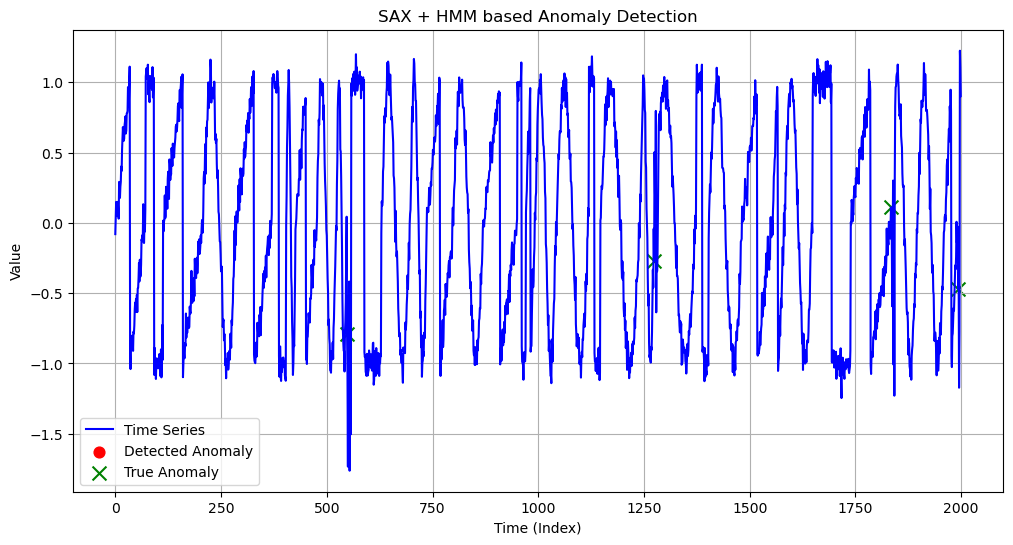

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog
from skimage.transform import resize
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import precision_score, recall_score

from saxpy.paa import paa
from saxpy.sax import ts_to_string, cuts_for_asize
from hmmlearn import hmm


def evaluate_performance(true_anomalies, detected_anomalies, tolerance=20):
    y_true = np.zeros(len(data))
    for idx in true_anomalies:
        y_true[max(0, idx - tolerance):min(len(data), idx + tolerance)] = 1  # 允許範圍內都算異常
    
    y_pred = np.zeros(len(data))
    for idx in detected_anomalies:
        y_pred[idx] = 1  # 只標示預測到的異常點
    
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return precision, recall

# Convert time series to SAX representation
def extract_features_sax(data, window_size=64, step=16, alphabet_size=6, paa_segments=10):
    features = []
    indices = []
    
    for start in range(0, len(data) - window_size + 1, step):
        window = data[start:start + window_size]
        paa_rep = paa(window, paa_segments)
        sax_rep = ts_to_string(paa_rep, cuts_for_asize(alphabet_size))
        features.append([ord(c) - ord('a') for c in sax_rep])  # Convert letters to numerical values
        indices.append(start + window_size // 2)
    
    return np.array(features), np.array(indices)

# Train HMM model for anomaly detection
def train_hmm(features, n_components=3):
    model = hmm.GaussianHMM(n_components=n_components, covariance_type="diag", n_iter=1000)
    model.fit(features)
    return model

# Main execution with SAX + HMM
iteration = 0
precision, recall = 0, 0


# Generate data
data, true_anomaly_idx = simulate_multimodal_series(n=2000, anomaly_frac=0.15)

# Feature extraction
window_size = 64
step = 16
X, win_indices = extract_features_sax(data, window_size, step)

# Train HMM
hmm_model = train_hmm(X)

# Compute log-likelihood scores
log_probs = hmm_model.score_samples(X)[0]

# Identify anomalies (lowest 15% log-likelihood scores)
threshold = np.percentile(log_probs, 15)
detected_anomaly_idx = win_indices[log_probs < threshold]

# Evaluate model
precision, recall = evaluate_performance(true_anomaly_idx, detected_anomaly_idx, len(data))


plt.figure(figsize=(12, 6))
plt.plot(data, label="Time Series", color="blue")
plt.scatter(detected_anomaly_idx, data[detected_anomaly_idx], color="red", marker="o", s=60, label="Detected Anomaly")
plt.scatter(true_anomaly_idx, data[true_anomaly_idx], color="green", marker="x", s=100, label="True Anomaly")
plt.title("SAX + HMM based Anomaly Detection")
plt.xlabel("Time (Index)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
!pip install hmmlearn

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/127.0 kB ? eta -:--:--
     --- ------------------------------------ 10.2/127.0 kB ? eta -:--:--
     --- ------------------------------------ 10.2/127.0 kB ? eta -:--:--
     --- ------------------------------------ 10.2/127.0 kB ? eta -:--:--
     --- ------------------------------------ 10.2/127.0 kB ? eta -:--:--
     ----------- ------------------------- 41.0/127.0 kB 140.9 kB/s eta 0:00:01
     ----------------- ------------------- 61.4/127.0 kB 218.8 kB/s eta 0:00:01
     ----------------- ------------------- 61.4/127.0 kB 218.8 kB/s eta 0:00:01
     -------------------------- ---------- 92.2/127.0 kB 228.2 kB/s eta 0:00:01
     -------------------------- ---------- 92.2/127.0 kB 228.2 kB/s eta 0:00:01
     -------------------------- ---------- 92.2/127.0 kB 228.2 kB/s eta 0:00:01
     ------------------------------------ 127.0/127.0 kB 241.3 kB/s eta 0:00:00
